<a href="https://colab.research.google.com/github/meghanagogineni2005-svg/data-science-python-internship/blob/main/Week_4_Machine_Learning_Model_Development_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Set visualization style
sns.set_style("whitegrid")

# Display confirmation
print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
from google.colab import files
import zipfile
import os

# Upload the ZIP file
uploaded = files.upload()

# Extract the ZIP file
zip_file = next(iter(uploaded))

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/student_data')

# Display extracted files
for root, dirs, filenames in os.walk('/content/student_data'):
    for filename in filenames:
        print(os.path.join(root, filename))

Saving student+performance.zip to student+performance (1).zip
/content/student_data/.student.zip_old
/content/student_data/student.zip


In [5]:
import zipfile
import os

# Extract the inner ZIP file
inner_zip = "/content/student_data/student.zip"

with zipfile.ZipFile(inner_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/student_data/extracted')

# Display extracted files
for root, dirs, filenames in os.walk('/content/student_data/extracted'):
    for filename in filenames:
        print(os.path.join(root, filename))

/content/student_data/extracted/student-merge.R
/content/student_data/extracted/student-por.csv
/content/student_data/extracted/student.txt
/content/student_data/extracted/student-mat.csv


In [6]:
import pandas as pd

df = pd.read_csv(
    "/content/student_data/extracted/student-por.csv",
    sep=";"
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [7]:
# Create binary target variable
df["pass"] = (df["G3"] >= 10).astype(int)

# Check the distribution of pass and fail
print(df["pass"].value_counts())
print("\nPass/fail percentages:")
print(df["pass"].value_counts(normalize=True) * 100)

pass
1    549
0    100
Name: count, dtype: int64

Pass/fail percentages:
pass
1    84.59168
0    15.40832
Name: proportion, dtype: float64


In [8]:
# Separate features and target
X = df.drop(columns=["G1", "G2", "G3", "pass"])
y = df["pass"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("\nCategorical columns:", list(categorical_cols))
print("\nNumerical columns:", list(numerical_cols))

Features shape: (649, 30)
Target shape: (649,)

Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Preprocess numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (519, 30)
Testing features: (130, 30)
Training target: (519,)
Testing target: (130,)


In [10]:
from sklearn.linear_model import LogisticRegression

# Create the complete machine learning pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Model Evaluation Results")
print("------------------------")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fail", "Pass"],
    zero_division=0
))

Model Evaluation Results
------------------------
Accuracy:  0.7923
Precision: 0.8673
Recall:    0.8909
F1-score:  0.8789

Classification Report:
              precision    recall  f1-score   support

        Fail       0.29      0.25      0.27        20
        Pass       0.87      0.89      0.88       110

    accuracy                           0.79       130
   macro avg       0.58      0.57      0.57       130
weighted avg       0.78      0.79      0.79       130



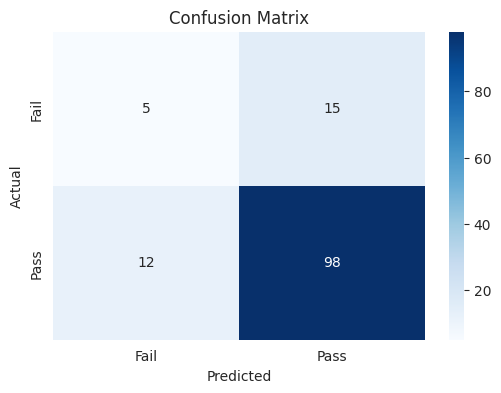

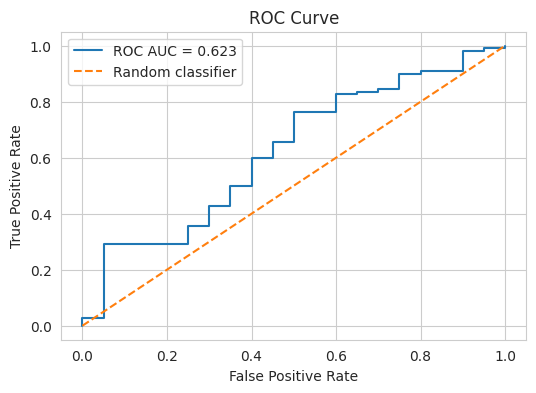

ROC-AUC: 0.6227


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC curve
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC:", round(roc_auc, 4))

MODEL EVALUATION RESULTS
Accuracy:  0.7923
Precision: 0.8673
Recall:    0.8909
F1-score:  0.8789
ROC-AUC:   0.6227

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Fail       0.29      0.25      0.27        20
        Pass       0.87      0.89      0.88       110

    accuracy                           0.79       130
   macro avg       0.58      0.57      0.57       130
weighted avg       0.78      0.79      0.79       130

CONFUSION MATRIX
[[ 5 15]
 [12 98]]


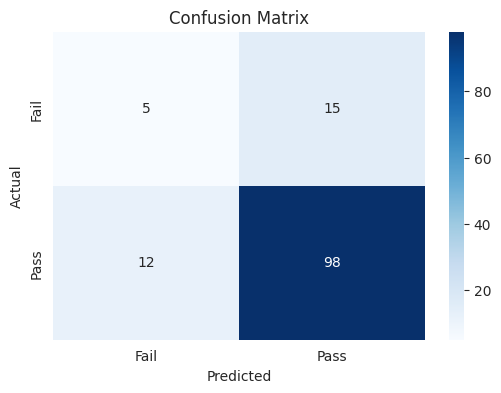

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions using the trained model
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
print("MODEL EVALUATION RESULTS")
print("=" * 35)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")

# Print classification report
print("\nCLASSIFICATION REPORT")
print("=" * 35)
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Fail", "Pass"],
    zero_division=0
))

# Generate confusion matrix from the same predictions
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

print("CONFUSION MATRIX")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()